# DCGAN Implementation Comparison

**Objective**: Reproduce DCGAN results

## Section 1: Import Required Libraries and Set Up Environment

This section imports all necessary libraries for building, training, and evaluating the DCGAN. It also sets up the device (CPU/GPU) for computation and defines a utility function `show_images` for visualizing generated samples.

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def show_images(images, nrow=4, title="Generated Images"):
    images = (images + 1) / 2  # Un-normalize from [-1, 1] to [0, 1]
    grid = make_grid(images, nrow=nrow).detach().cpu().numpy()
    plt.figure(figsize=(6, 6))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

Using device: cuda


## Section 2: DCGAN Model Architecture

This section defines the core components of the DCGAN: the `weights_init` function for custom weight initialization, the `Generator` class responsible for creating synthetic images, and the `Discriminator` class tasked with distinguishing real images from fake ones.

In [3]:
def weights_init(m):
    """Custom weight initialization based on the DCGAN paper."""
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self, latent_dim, im_size, im_channels, conv_channels, kernels, strides, paddings):
        super().__init__()
        self.latent_dim = latent_dim
        self.im_size = im_size
        self.im_channels = im_channels

        activation = nn.ReLU()
        layers_dim = [self.latent_dim] + conv_channels + [self.im_channels]

        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.ConvTranspose2d(layers_dim[i], layers_dim[i+1],
                                   kernel_size=kernels[i],
                                   stride=strides[i],
                                   padding=paddings[i],
                                   bias=False),
                nn.BatchNorm2d(layers_dim[i+1]) if i != len(layers_dim)-2 else nn.Identity(),
                activation if i != len(layers_dim)-2 else nn.Tanh()
            )
            for i in range(len(layers_dim)-1)
        ])

    def forward(self, z):
        batch_size = z.shape[0]
        out = z.reshape(-1, self.latent_dim, 1, 1)
        for layer in self.layers:
            out = layer(out)
        out = out.view(batch_size, self.im_channels, self.im_size, self.im_size)
        return out

class Discriminator(nn.Module):
    def __init__(self, im_size, im_channels, conv_channels, kernels, strides, paddings):
        super().__init__()
        self.im_size = im_size
        self.im_channels = im_channels

        # Paper specifies 0.2 leak for Discriminator
        activation = nn.LeakyReLU(0.2)
        layers_dim = [self.im_channels] + conv_channels + [1]

        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(layers_dim[i], layers_dim[i+1],
                          kernel_size=kernels[i],
                          stride=strides[i],
                          padding=paddings[i],
                          bias=False),
                nn.BatchNorm2d(layers_dim[i+1]) if i != len(layers_dim)-2 and i != 0 else nn.Identity(),
                activation if i != len(layers_dim)-2 else nn.Identity()
            )
            for i in range(len(layers_dim)-1)
        ])

    def forward(self, x):
        out = x
        for layer in self.layers:
            out = layer(out)
        return out.reshape(x.size(0))

## Section 3: Training and Evaluation Functions

This section contains the main functions for training the DCGAN and evaluating the quality of its generated features:
- `train_dcgan`: Implements the adversarial training loop for the Generator and Discriminator.
- `extract_and_evaluate_svm`: Extracts features from the Discriminator's intermediate layers and evaluates their quality using a Linear Support Vector Machine (L2-SVM) classifier.

In [4]:
def train_dcgan(generator, discriminator, dataloader, config):
    """Handles the training loop for the DCGAN."""
    optimizer_generator = Adam(generator.parameters(), lr=config['lr'], betas=(0.5, 0.999))
    optimizer_discriminator = Adam(discriminator.parameters(), lr=config['lr'], betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    fixed_noise = torch.randn((16, config['latent_dim']), device=device)
    all_G_losses, all_D_losses = [], []

    generator.train()
    discriminator.train()

    for epoch in range(config['num_epochs']):
        g_losses, d_losses = [], []

        for im, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{config['num_epochs']}"):
            real_ims = im.float().to(device)
            batch_size = real_ims.shape[0]

            # Train Discriminator
            optimizer_discriminator.zero_grad()
            fake_noise = torch.randn((batch_size, config['latent_dim']), device=device)
            fake_ims = generator(fake_noise)

            real_label = torch.ones((batch_size, 1), device=device)
            fake_label = torch.zeros((batch_size, 1), device=device)

            disc_real_pred = discriminator(real_ims)
            disc_fake_pred = discriminator(fake_ims.detach())

            disc_loss = (criterion(disc_real_pred.reshape(-1), real_label.reshape(-1)) +
                         criterion(disc_fake_pred.reshape(-1), fake_label.reshape(-1))) / 2
            disc_loss.backward()
            optimizer_discriminator.step()

            # Train Generator
            optimizer_generator.zero_grad()
            disc_fake_pred_gen = discriminator(fake_ims)
            gen_loss = criterion(disc_fake_pred_gen.reshape(-1), real_label.reshape(-1))
            gen_loss.backward()
            optimizer_generator.step()

            g_losses.append(gen_loss.item())
            d_losses.append(disc_loss.item())

        all_G_losses.append(np.mean(g_losses))
        all_D_losses.append(np.mean(d_losses))
        print(f"Epoch {epoch+1} | G Loss: {np.mean(g_losses):.4f} | D Loss: {np.mean(d_losses):.4f}")

    # Show final generation
    generator.eval()
    with torch.no_grad():
        show_images(generator(fixed_noise), nrow=4, title="Final Generation")
    return generator, discriminator


def extract_and_evaluate_svm(discriminator, train_loader, test_loader, num_train_samples=None):
    """Extracts features from all discriminator layers and runs L2-SVM classification."""
    max_pool = nn.AdaptiveMaxPool2d((4, 4)).to(device)
    intermediate_features = []

    def hook_fn(module, input, output):
        intermediate_features.append(output)

    # Attach hooks to all conv layers except final classification
    hooks = [layer.register_forward_hook(hook_fn) for layer in discriminator.layers[:-1]]

    def extract(dataloader, max_samples):
        discriminator.eval()
        features_list, labels_list = [], []

        with torch.no_grad():
            for imgs, targets in tqdm(dataloader, desc="Extracting Features"):
                if max_samples and len(features_list) * dataloader.batch_size >= max_samples:
                    break

                intermediate_features.clear()
                _ = discriminator(imgs.float().to(device))

                batch_features = []
                for feats in intermediate_features:
                    pooled = max_pool(feats)
                    batch_features.append(pooled.view(pooled.size(0), -1))

                concat_feats = torch.cat(batch_features, dim=1).cpu().numpy()
                features_list.append(concat_feats)
                labels_list.append(targets.numpy())

        X = np.vstack(features_list)
        y = np.concatenate(labels_list)
        return X[:max_samples] if max_samples else X, y[:max_samples] if max_samples else y

    print("Extracting Training Features...")
    X_train, y_train = extract(train_loader, num_train_samples)
    print("Extracting Testing Features...")
    X_test, y_test = extract(test_loader, None) # Always test on full test set

    for hook in hooks: hook.remove()

    print(f"\nTraining L2-SVM on {X_train.shape[0]} samples with {X_train.shape[1]} features...")
    svm_clf = LinearSVC(C=1.0, max_iter=5000, random_state=42, dual=False)
    svm_clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, svm_clf.predict(X_train)) * 100
    test_acc = accuracy_score(y_test, svm_clf.predict(X_test)) * 100

    print("=" * 50)
    print(f"Results:")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Test Accuracy:  {test_acc:.2f}%")
    print(f"Test Error:     {100 - test_acc:.2f}%")
    print("=" * 50)

## Section 4: Configuration and Data Loading (CIFAR-10)

This section defines the configuration parameters for the DCGAN, tailored for 32x32 RGB datasets like CIFAR-10. It also handles the loading and preprocessing of the CIFAR-10 dataset.

In [5]:
# Configuration for 32x32 RGB datasets (CIFAR-10 & SVHN)
config_32x32 = {
    'latent_dim': 100,
    'im_size': 32,
    'im_channels': 3,
    'generator_channels': [256, 128, 64],
    'generator_kernels': [4, 4, 4, 4],
    'generator_strides': [1, 2, 2, 2],
    'generator_paddings': [0, 1, 1, 1],
    'discriminator_channels': [64, 128, 256],
    'discriminator_kernels': [4, 4, 4, 4],
    'discriminator_strides': [2, 2, 2, 1],
    'discriminator_paddings': [1, 1, 1, 0],
    'batch_size': 16,
    'lr': 0.0002,
    'num_epochs': 20 # Can lower to 10 for faster testing
}

transform_32 = transforms.Compose([
    transforms.Resize(config_32x32['im_size']),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

print("Downloading CIFAR-10...")
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_32)
cifar_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_32)

cifar_train_loader = DataLoader(cifar_train, batch_size=config_32x32['batch_size'], shuffle=True, drop_last=True)
cifar_test_loader = DataLoader(cifar_test, batch_size=128, shuffle=False)

### CIFAR-10 Experiment

This code block initiates the DCGAN training and evaluation process for the CIFAR-10 dataset. It involves:
1.  **Instantiating Models**: Creating new Generator and Discriminator models.
2.  **Training Models**: Executing the `train_dcgan` function.
3.  **Evaluating Features**: Using `extract_and_evaluate_svm` to assess the Discriminator's feature extraction capabilities.

--- STARTING CIFAR-10 EXPERIMENT ---


Epoch 1/20:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 1 | G Loss: 3.2503 | D Loss: 0.3141


Epoch 2/20:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 2 | G Loss: 2.3123 | D Loss: 0.4048


...

Epoch 18 | G Loss: 3.2569 | D Loss: 0.2542


Epoch 19/20:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 19 | G Loss: 3.3284 | D Loss: 0.2483


Epoch 20/20:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 20 | G Loss: 3.3966 | D Loss: 0.2357


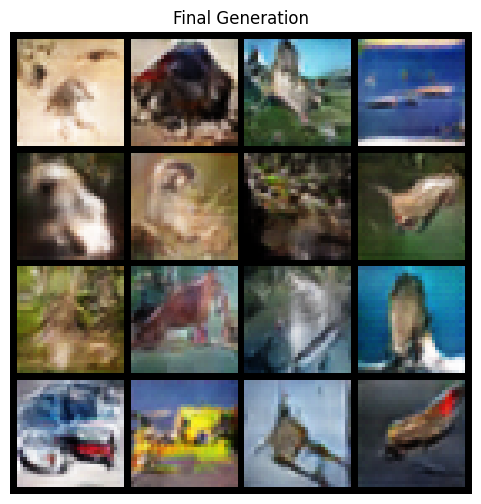

Extracting Training Features...


Extracting Features:   0%|          | 0/3125 [00:00<?, ?it/s]

Extracting Testing Features...


Extracting Features:   0%|          | 0/79 [00:00<?, ?it/s]


Training L2-SVM on 1000 samples with 7168 features...
Results:
Train Accuracy: 100.00%
Test Accuracy:  54.02%
Test Error:     45.98%


In [6]:
print("--- STARTING CIFAR-10 EXPERIMENT ---")

# 1. Instantiate Models
gen_cifar = Generator(config_32x32['latent_dim'], config_32x32['im_size'], config_32x32['im_channels'],
                      config_32x32['generator_channels'], config_32x32['generator_kernels'],
                      config_32x32['generator_strides'], config_32x32['generator_paddings']).to(device)

disc_cifar = Discriminator(config_32x32['im_size'], config_32x32['im_channels'],
                           config_32x32['discriminator_channels'], config_32x32['discriminator_kernels'],
                           config_32x32['discriminator_strides'], config_32x32['discriminator_paddings']).to(device)

gen_cifar.apply(weights_init)
disc_cifar.apply(weights_init)

# 2. Train Models
gen_cifar, disc_cifar = train_dcgan(gen_cifar, disc_cifar, cifar_train_loader, config_32x32)

# 3. Evaluate Features (Full dataset evaluation as per Table 1)
# Note: For strict adherence to the paper's max 400 per class, you can filter the dataset,
# but setting num_train_samples to None evaluates general feature quality on the full set.
extract_and_evaluate_svm(disc_cifar, cifar_train_loader, cifar_test_loader, num_train_samples=1000)

## Section 5: Data Loading (SVHN)

This section handles the loading and preprocessing of the Street View House Numbers (SVHN) dataset, using the same transformations defined for CIFAR-10.

In [7]:
print("Downloading SVHN...")
svhn_train = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform_32)
svhn_test = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=transform_32)

svhn_train_loader = DataLoader(svhn_train, batch_size=config_32x32['batch_size'], shuffle=True, drop_last=True)
svhn_test_loader = DataLoader(svhn_test, batch_size=128, shuffle=False)

100%|██████████| 182M/182M [00:02<00:00, 76.6MB/s]
100%|██████████| 64.3M/64.3M [00:09<00:00, 6.83MB/s]


### SVHN Experiment

This code block repeats the DCGAN training and evaluation process, this time for the SVHN dataset. It ensures that new models are instantiated and trained specifically for SVHN, followed by feature evaluation.

--- STARTING SVHN EXPERIMENT ---


Epoch 1/20:   0%|          | 0/4578 [00:00<?, ?it/s]

Epoch 1 | G Loss: 2.6771 | D Loss: 0.3792


Epoch 2/20:   0%|          | 0/4578 [00:00<?, ?it/s]

Epoch 2 | G Loss: 2.3522 | D Loss: 0.3629


...

Epoch 18 | G Loss: 2.8929 | D Loss: 0.3109


Epoch 19/20:   0%|          | 0/4578 [00:00<?, ?it/s]

Epoch 19 | G Loss: 2.9337 | D Loss: 0.3096


Epoch 20/20:   0%|          | 0/4578 [00:00<?, ?it/s]

Epoch 20 | G Loss: 2.9691 | D Loss: 0.3022


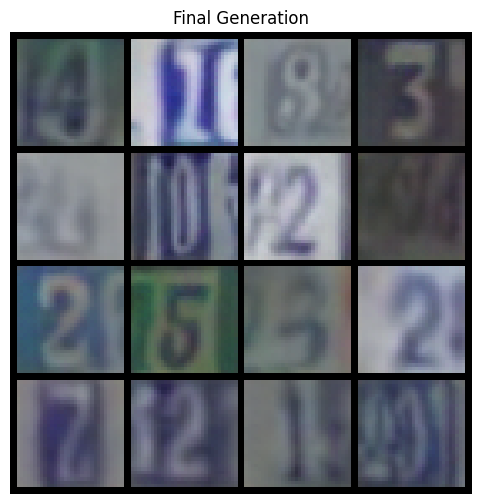

Extracting Training Features...


Extracting Features:   0%|          | 0/4578 [00:00<?, ?it/s]

Extracting Testing Features...


Extracting Features:   0%|          | 0/204 [00:00<?, ?it/s]


Training L2-SVM on 1000 samples with 7168 features...
Results:
Train Accuracy: 100.00%
Test Accuracy:  74.87%
Test Error:     25.13%


In [8]:
print("--- STARTING SVHN EXPERIMENT ---")

# 1. Instantiate Brand New Models for SVHN
gen_svhn = Generator(config_32x32['latent_dim'], config_32x32['im_size'], config_32x32['im_channels'],
                      config_32x32['generator_channels'], config_32x32['generator_kernels'],
                      config_32x32['generator_strides'], config_32x32['generator_paddings']).to(device)

disc_svhn = Discriminator(config_32x32['im_size'], config_32x32['im_channels'],
                           config_32x32['discriminator_channels'], config_32x32['discriminator_kernels'],
                           config_32x32['discriminator_strides'], config_32x32['discriminator_paddings']).to(device)

gen_svhn.apply(weights_init)
disc_svhn.apply(weights_init)

# 2. Train Models
gen_svhn, disc_svhn = train_dcgan(gen_svhn, disc_svhn, svhn_train_loader, config_32x32)

# 3. Evaluate Features (Restricted to exactly 1000 labels as per Table 2)
extract_and_evaluate_svm(disc_svhn, svhn_train_loader, svhn_test_loader, num_train_samples=1000)